# Multi-redshift training data — explore & validate

The `feature/redshift` dataset (`train_data_multiz_128_cpu`) stores, per
(simulation, snapshot, halo), the usual mass maps **plus** the 4 gas-thermo maps
**plus** the snapshot `redshift` / `scale_factor`, in a nested layout
`train/sim_i/snap_NNN/sim_i_halo_k_rot_0.npz` (1 rotation each, 8 snapshots z=0–4).

This notebook (1) inventories what's present, (2) checks one file's keys/shapes,
(3) shows all channels across redshift for one halo, (4) confirms
`scale_factor = 1/(1+redshift)`, (5) **cross-checks z=0 against the original
`train_data_rotated2_128_cpu`** (should be bit-for-bit identical — same seed,
a=1), and (6) sanity-checks the (unvalidated) z>0 thermo scaling.


In [10]:
import os, glob
import numpy as np
import matplotlib.pyplot as plt

from bind.data import z_to_a, a_to_z, SNAPSHOT_REDSHIFTS, THERMO_KEYS

DATA_ROOT = '/mnt/home/mlee1/ceph/train_data_multiz_128_cpu'
ORIG_ROOT = '/mnt/home/mlee1/ceph/train_data_rotated2_128_cpu'  # original z=0 (10 rot) data

MASS_NAMES = ['DM_hydro', 'Gas', 'Stars']
# display order: 3 mass channels then the 4 thermo channels
CHANNELS = MASS_NAMES + list(THERMO_KEYS)

def sim_dir(sim, split='train'):
    return os.path.join(DATA_ROOT, split, f'sim_{sim}')

def snaps_for(sim, split='train'):
    '''Sorted list of (snap_int, redshift, dir) present for a sim.'''
    out = []
    for d in sorted(glob.glob(sim_dir(sim, split) + '/snap_*/')):
        sn = int(d.rstrip('/').split('snap_')[-1])
        out.append((sn, SNAPSHOT_REDSHIFTS.get(sn, np.nan), d))
    return sorted(out, key=lambda t: t[1])  # by redshift

def load_sample(sim, snap_int, halo, split='train'):
    f = os.path.join(sim_dir(sim, split), f'snap_{snap_int:03d}',
                     f'sim_{sim}_halo_{halo}_rot_0.npz')
    return np.load(f) if os.path.exists(f) else None

def channel(d, name):
    if name in MASS_NAMES:
        return d['target'][MASS_NAMES.index(name)]
    return d[name]

def show_log(ax, img):
    '''log10 imshow that is robust to zeros/negatives.'''
    a = np.asarray(img, float)
    pos = a[a > 0]
    m = np.log10(np.where(a > 0, a, np.nan))
    vmin = np.percentile(np.log10(pos), 2) if pos.size else None
    ax.imshow(m, origin='lower', vmin=vmin)
    ax.set_xticks([]); ax.set_yticks([])


## 1. Inventory — which sims / snapshots are on disk
(Generation may still be running, so this reflects a partial set.)

In [11]:
train_sims = sorted(int(p.split('sim_')[-1]) for p in glob.glob(DATA_ROOT + '/train/sim_*'))
test_sims  = sorted(int(p.split('sim_')[-1]) for p in glob.glob(DATA_ROOT + '/test/sim_*'))
print(f'{len(train_sims)} train sims, {len(test_sims)} test sims present')

# pick the sim with the most snapshots on disk for the figures below
best = max(train_sims, key=lambda s: len(snaps_for(s))) if train_sims else None
SIM = best
print(f'using SIM={SIM}; snapshots present:')
for sn, z, _ in snaps_for(SIM):
    n = len(glob.glob(os.path.join(sim_dir(SIM), f'snap_{sn:03d}', '*.npz')))
    print(f'  snap_{sn:03d}  z={z:.2f}  ({n} halo files)')


126 train sims, 15 test sims present
using SIM=10; snapshots present:
  snap_060  z=1.05  (3 halo files)
  snap_044  z=2.00  (3 halo files)


## 2. One file — keys, shapes, redshift, finiteness

In [12]:
sn0, z0, _ = snaps_for(SIM)[0]
# first available halo in that snapshot
some = sorted(glob.glob(os.path.join(sim_dir(SIM), f'snap_{sn0:03d}', '*.npz')))[0]
d = np.load(some)
print('file:', os.path.relpath(some, DATA_ROOT))
print('keys:', sorted(d.files))
for k in ['condition','target','large_scale','params','redshift','scale_factor', *THERMO_KEYS]:
    v = d[k]
    if v.ndim == 0:
        print(f'  {k:13s} scalar = {float(v):.5f}')
    else:
        print(f'  {k:13s} shape={v.shape}  finite={np.isfinite(v).all()}  '
              f'range=[{np.nanmin(v):.3g}, {np.nanmax(v):.3g}]')


file: train/sim_10/snap_060/sim_10_halo_0_rot_0.npz
keys: ['compton_y', 'condition', 'entropy', 'halo_center', 'halo_mass', 'large_scale', 'params', 'pressure', 'redshift', 'scale_factor', 'target', 'temperature']
  condition     shape=(128, 128)  finite=True  range=[1.77e+09, 2.18e+12]
  target        shape=(3, 128, 128)  finite=True  range=[0, 1.59e+12]
  large_scale   shape=(3, 128, 128)  finite=True  range=[1.29e+09, 1.44e+12]
  params        shape=(35,)  finite=True  range=[-2.64, 613]
  redshift      scalar = 1.04457
  scale_factor  scalar = 0.48910
  compton_y     shape=(128, 128)  finite=True  range=[1.42e-10, 5.02e-05]
  temperature   shape=(128, 128)  finite=True  range=[1.59e+04, 3.82e+07]
  entropy       shape=(128, 128)  finite=True  range=[6.26, 2.77e+03]
  pressure      shape=(128, 128)  finite=True  range=[1.32e-18, 7.19e-12]


## 3. All channels across redshift, one halo

Rows = channels (3 mass + 4 thermo), columns = snapshots (low→high z).

⚠ **Halos are indexed per snapshot** (independent FOF catalogs sorted by mass), so
`halo_k` is *not the same object* across redshift — this shows how the fields
*look* at each epoch, not a tracked merger history. High-z snapshots also have
far fewer >10¹³ M⊙ halos, so `halo_k` may be absent there (panel left blank).

In [22]:
channel(d, 'target')[2]

array([[0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 0.0000000e+00,
        5.0090100e+06, 1.9112718e+06],
       [0.0000000e+00, 0.0000000e+00, 0.0000000e+00, ..., 3.5927458e+06,
        1.7225341e+06, 6.5726175e+05],
       [4.2982290e+06, 1.2472615e+06, 0.0000000e+00, ..., 4.6146640e+06,
        0.0000000e+00, 0.0000000e+00],
       ...,
       [8.5564262e+05, 1.8932609e+06, 0.0000000e+00, ..., 1.8865810e+07,
        3.0237490e+07, 4.9806470e+06],
       [1.1348079e+07, 4.1942904e+07, 2.5463748e+06, ..., 1.8781772e+07,
        5.0174664e+07, 1.1280586e+07],
       [5.3908764e+07, 6.7785816e+07, 1.8540358e+06, ..., 0.0000000e+00,
        1.6274708e+04, 2.4188433e+03]], dtype=float32)

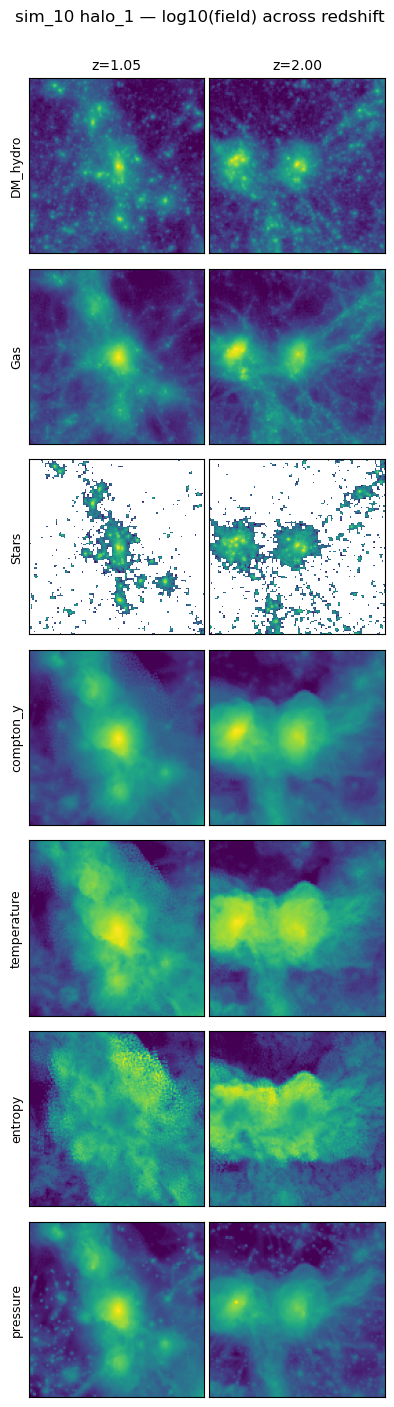

In [13]:
HALO = 1   # change me
snaps = snaps_for(SIM)
fig, axs = plt.subplots(len(CHANNELS), len(snaps),
                        figsize=(2.0*len(snaps), 2.0*len(CHANNELS)), squeeze=False)
for j, (sn, z, _) in enumerate(snaps):
    d = load_sample(SIM, sn, HALO)
    axs[0, j].set_title(f'z={z:.2f}', fontsize=10)
    for i, name in enumerate(CHANNELS):
        ax = axs[i, j]
        if d is None:
            ax.set_facecolor('0.9'); ax.set_xticks([]); ax.set_yticks([])
        else:
            show_log(ax, channel(d, name))
        if j == 0:
            ax.set_ylabel(name, fontsize=9)
fig.suptitle(f'sim_{SIM} halo_{HALO} — log10(field) across redshift', y=1.002)
plt.tight_layout(); plt.show()


## 4. `scale_factor` consistency — should equal 1/(1+redshift)

In [14]:
rows = []
for sn, z, sdir in snaps_for(SIM):
    f = sorted(glob.glob(os.path.join(sdir, '*.npz')))
    if not f:
        continue
    d = np.load(f[0])
    zr, ar = float(d['redshift']), float(d['scale_factor'])
    rows.append((sn, zr, ar, 1.0/(1.0+zr), abs(ar - 1.0/(1.0+zr))))
print(f'{"snap":>5} {"z(file)":>9} {"a(file)":>9} {"1/(1+z)":>9} {"|diff|":>9}')
for sn, zr, ar, aexp, diff in rows:
    print(f'{sn:5d} {zr:9.4f} {ar:9.4f} {aexp:9.4f} {diff:9.2e}')
assert all(diff < 1e-4 for *_, diff in rows), 'scale_factor != 1/(1+z)!'
print('\nOK: scale_factor == 1/(1+redshift) for every snapshot.')


 snap   z(file)   a(file)   1/(1+z)    |diff|
   60    1.0446    0.4891    0.4891  6.85e-09
   44    2.0003    0.3333    0.3333  1.56e-08

OK: scale_factor == 1/(1+redshift) for every snapshot.


## 5. z=0 cross-check vs the original dataset

The multi-z `snap_090` (z=0) sample uses the same rotation seed
(`sim*1000 + halo*100 + 0`) and a=1 physics as the original
`train_data_rotated2_128_cpu`, so the two should match **bit-for-bit** (mass)
and to round-off (thermo). A large diff means the merged pipeline drifted from
the validated z=0 path.

In [15]:
def orig_path(sim, halo, split):
    return os.path.join(ORIG_ROOT, split, f'sim_{sim}', f'sim_{sim}_halo_{halo}_rot_0.npz')

# find a sim+halo present in BOTH multi-z snap_090 and the original data
pair = None
for split in ('train', 'test'):
    for p in sorted(glob.glob(os.path.join(DATA_ROOT, split, 'sim_*', 'snap_090', '*.npz'))):
        sim = int(p.split('sim_')[1].split('/')[0])
        halo = int(p.split('_halo_')[1].split('_rot')[0])
        if os.path.exists(orig_path(sim, halo, split)):
            pair = (split, sim, halo, p); break
    if pair: break

if pair is None:
    print('No overlapping (sim,halo) yet — snap_090 still generating. Re-run later.')
else:
    split, sim, halo, mzp = pair
    mz = np.load(mzp); og = np.load(orig_path(sim, halo, split))
    print(f'comparing sim_{sim} halo_{halo} ({split}):  multi-z snap_090  vs  original\n')
    for k in ['condition', 'target', 'large_scale', *THERMO_KEYS]:
        if k in og.files:
            a, b = np.asarray(mz[k], float), np.asarray(og[k], float)
            denom = np.maximum(np.abs(b).max(), 1e-30)
            print(f'  {k:13s} max|Δ|={np.abs(a-b).max():.3e}  '
                  f'max|Δ|/scale={np.abs(a-b).max()/denom:.2e}')
        else:
            print(f'  {k:13s} (not in original file)')


comparing sim_1014 halo_0 (train):  multi-z snap_090  vs  original

  condition     max|Δ|=0.000e+00  max|Δ|/scale=0.00e+00
  target        max|Δ|=3.645e+05  max|Δ|/scale=9.12e-07
  large_scale   max|Δ|=0.000e+00  max|Δ|/scale=0.00e+00
  compton_y     max|Δ|=0.000e+00  max|Δ|/scale=0.00e+00
  temperature   max|Δ|=0.000e+00  max|Δ|/scale=0.00e+00
  entropy       max|Δ|=0.000e+00  max|Δ|/scale=0.00e+00
  pressure      max|Δ|=0.000e+00  max|Δ|/scale=0.00e+00


## 6. z>0 thermo sanity — the part to scrutinize

The z>0 thermo maps carry comoving→physical scale-factor factors that are
**unvalidated** against an independent reference. As a sanity check, compare the
median of each thermo channel (over occupied pixels) across redshift. Expect
physical pressure/entropy and Compton-y to rise toward high z (smaller proper
volume); temperature is a-independent. Eyeball that nothing is absurd (e.g. all
zeros, or off by many orders of magnitude between adjacent snapshots).

In [7]:
def med_pos(img):
    a = np.asarray(img, float); pos = a[a > 0]
    return np.median(pos) if pos.size else np.nan

snaps = snaps_for(SIM)
print(f'{"z":>6} ' + ' '.join(f'{k:>12}' for k in THERMO_KEYS))
for sn, z, sdir in snaps:
    fs = sorted(glob.glob(os.path.join(sdir, '*.npz')))[:20]  # avg a few halos
    if not fs:
        continue
    meds = {k: np.nanmedian([med_pos(np.load(f)[k]) for f in fs]) for k in THERMO_KEYS}
    print(f'{z:6.2f} ' + ' '.join(f'{meds[k]:12.3e}' for k in THERMO_KEYS))


     z    compton_y  temperature      entropy     pressure
  0.00    7.432e-09    2.469e+06    3.781e+03    9.298e-17
  0.21    9.454e-09    1.963e+06    2.041e+03    1.348e-16
  0.47    7.613e-09    1.301e+06    8.553e+02    1.687e-16
  1.05    2.887e-08    1.339e+06    3.256e+02    9.054e-16
  1.48    9.692e-09    5.425e+05    9.768e+01    5.338e-16
  2.00    1.173e-08    3.817e+05    4.860e+01    7.389e-16
  3.01    1.184e-08    1.973e+05    1.250e+01    1.267e-15
